# Outcome shape × cell — where the golden set teaches and where it doesn't

Every labelled query lands in one of three outcome shapes (`labels.py`):

- **`routes_differ`** — one route clearly wins. The only shape that teaches
  the router dense-vs-sparse.
- **`all_tied`** — every route scores the same. Signal for "serve the
  cheapest", but inflated by shallow qrels (a single judged doc that every
  route ranks #1 ties at ceiling and proves nothing).
- **`all_zero`** — no route retrieved anything relevant; `route` is null.

The composition chose which queries enter the dataset, but nobody chose how
the shapes fall across the archetype cells. This notebook measures exactly
that: per cell, how much of its query mass actually carries routing signal.

**Inputs** (read-only, no retrieval, no network):
`data/route_labels/labels.parquet`, `data/composition/cell_selection.parquet`.


In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from hybrid_search_rrf_dataset.labels import (
    ALL_TIED,
    ALL_ZERO,
    DEFAULT_OUT_DIR,
    ROUTES_DIFFER,
)

SHAPES = [ROUTES_DIFFER, ALL_TIED, ALL_ZERO]

labels = pd.read_parquet(DEFAULT_OUT_DIR / "labels.parquet").astype({"query_id": str})
selection = pd.read_parquet(
    DEFAULT_OUT_DIR.parent / "composition" / "cell_selection.parquet"
).astype({"query_id": str})


def show(df: pd.DataFrame) -> None:
    display(Markdown(df.to_markdown()))


overall = labels["shape"].value_counts().reindex(SHAPES, fill_value=0)
print(f"{len(labels):,} labelled rows across {labels['dataset'].nunique()} datasets")
show(overall.to_frame("n").assign(share=lambda d: (d["n"] / d["n"].sum()).round(3)))

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


46,142 labelled rows across 42 datasets


| shape         |     n |   share |
|:--------------|------:|--------:|
| routes_differ | 22943 |   0.497 |
| all_tied      | 15018 |   0.325 |
| all_zero      |  8181 |   0.177 |

## 1 — Per-cell cross-tab (labels' own `cell` column)

Caveat before reading: `labels.parquet` carries **one** cell per query — a
query selected by several cells was deduped to a single one when the label
was written (`labels.py:237`). So a multi-cell query counts here once, under
one of its cells. Section 2 measures how much that dedup distorts the shares.

Sorted by `routes_differ` share ascending: the top rows are the cells the
router hears about least, relative to their size. Read `n` next to the share —
a high share over 30 queries is still less supervision than a mediocre share
over 3,000.


In [ ]:
def shape_table(frame: pd.DataFrame, by: str = "cell") -> pd.DataFrame:
    counts = (
        frame.pivot_table(
            index=by, columns="shape", values="query_id",
            aggfunc="count", fill_value=0,
        )
        .reindex(columns=SHAPES, fill_value=0)
    )
    counts["n"] = counts.sum(axis=1)
    shares = counts[SHAPES].div(counts["n"], axis=0)
    return counts.join(shares, rsuffix="_share").sort_values(f"{ROUTES_DIFFER}_share")


by_cell = shape_table(labels)
overall_differ = (labels["shape"] == ROUTES_DIFFER).mean()
print(f"overall {ROUTES_DIFFER} share: {overall_differ:.1%}  "
      f"(cells: {len(by_cell)})")
show(by_cell.round(3))

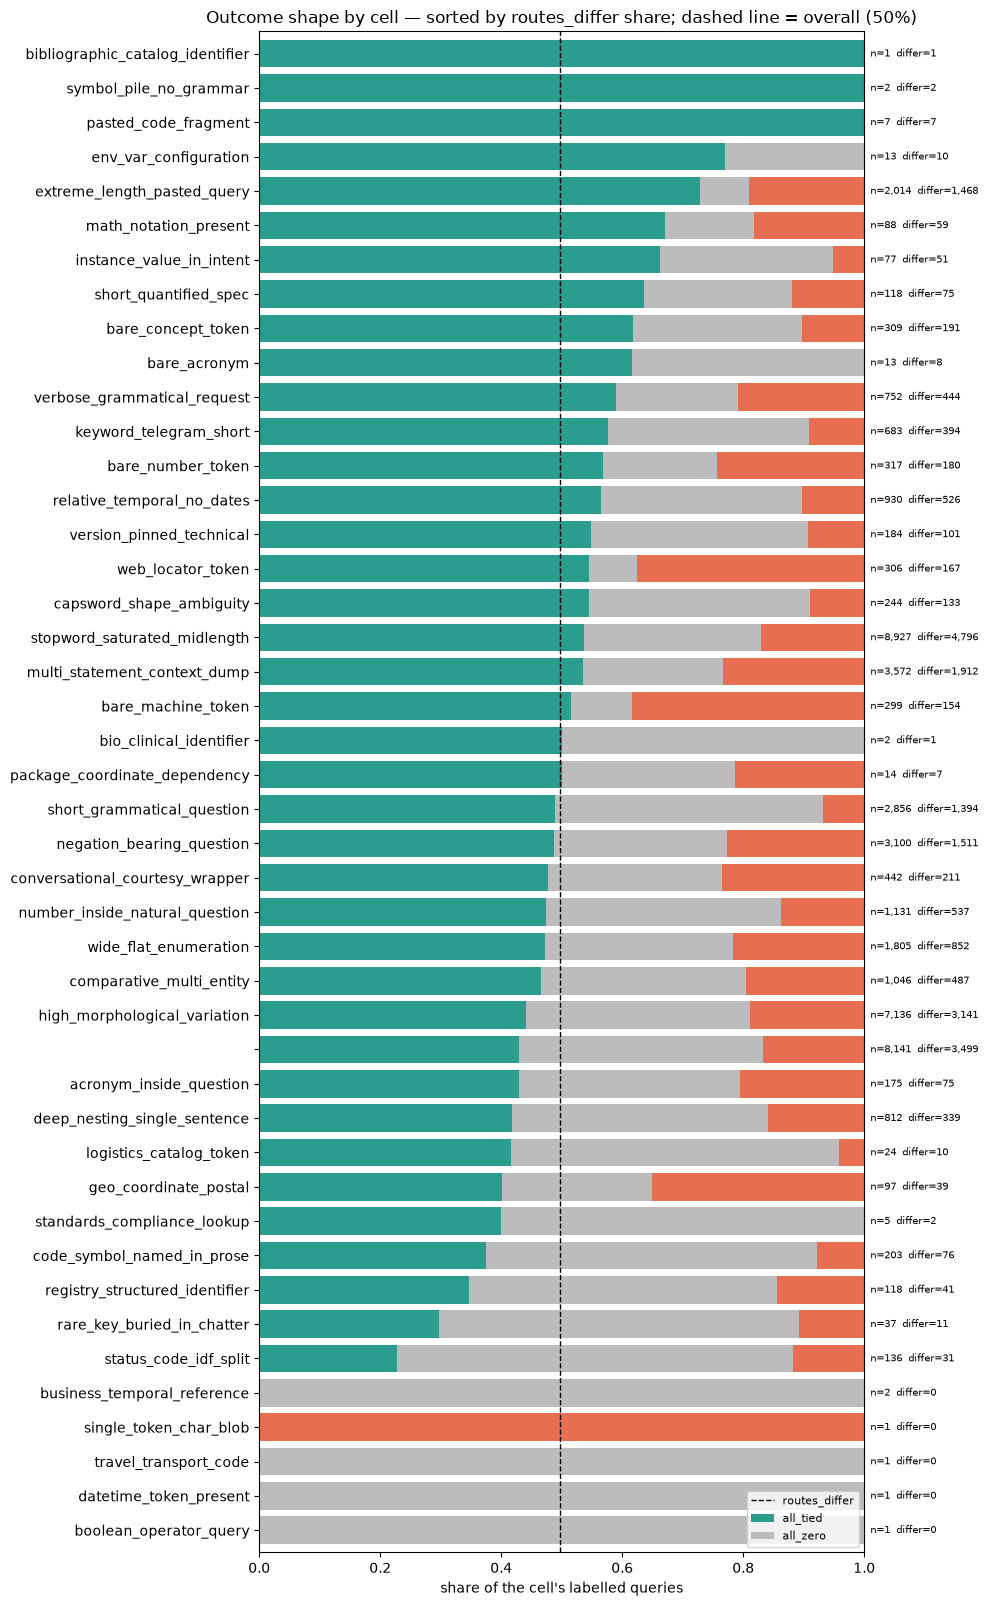

In [3]:
fig, ax = plt.subplots(figsize=(10, 0.34 * len(by_cell) + 1.2))
by_cell[[f"{s}_share" for s in SHAPES]].plot.barh(
    stacked=True, ax=ax, color=["#2a9d8f", "#bcbcbc", "#e76f51"], width=0.8,
)
ax.axvline(overall_differ, color="black", linestyle="--", linewidth=1)
for y, (_, row) in enumerate(by_cell.iterrows()):
    ax.text(1.01, y, f"n={int(row['n']):,}  differ={int(row[ROUTES_DIFFER]):,}",
            va="center", fontsize=7)
ax.set_xlim(0, 1)
ax.set_xlabel("share of the cell's labelled queries")
ax.set_ylabel("")
ax.set_title(f"Outcome shape by cell — sorted by {ROUTES_DIFFER} share; "
             f"dashed line = overall ({overall_differ:.0%})")
ax.legend([s for s in SHAPES], loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 1b — Is the per-cell spread real? Decompose against dataset

The table above shows spread, but cells draw their queries from different
dataset mixtures — and qrels depth (the tie inflator) is a **dataset**
property, not a cell property. So before reading any cell as tie-heavy or
signal-poor, ask how much of the shape variance each grouping actually
explains.

`eta²` = share of the shape indicator's variance explained by the grouping
(0 = the grouping tells you nothing, 1 = it determines the shape). The
decisive column is **`eta2_cell_after_dataset`**: what `cell` still explains
once each query's dataset baseline is subtracted. If that is ~0, the per-cell
table above is just the cells inheriting their datasets' shape mixtures, and
the shape axis lives in the **lane** dimension, not the cell dimension.

In [ ]:
def eta2(indicator: pd.Series, group: pd.Series) -> float:
    g = indicator.groupby(group).agg(["mean", "size"])
    grand = indicator.mean()
    between = (g["size"] * (g["mean"] - grand) ** 2).sum()
    return between / ((indicator - grand) ** 2).sum()


rows = []
for target in SHAPES:
    y = (labels["shape"] == target).astype(float)
    residual = y - y.groupby(labels["dataset"]).transform("mean")
    g = residual.groupby(labels["cell"]).agg(["mean", "size"])
    rows.append({
        "shape": target,
        "eta2_cell": eta2(y, labels["cell"]),
        "eta2_dataset": eta2(y, labels["dataset"]),
        "eta2_cell_after_dataset": (g["size"] * g["mean"] ** 2).sum()
        / (residual**2).sum(),
    })
show(pd.DataFrame(rows).set_index("shape").round(4))

show(shape_table(labels, by="dataset").round(3))

## How to read this

**Measured on the 2026-08-18 artifact: the cells do NOT drive the shape.**
`eta2_cell_after_dataset` ≈ 0.005 for `routes_differ` — once each query's
dataset baseline is subtracted, cell explains ~0.5% of the shape variance.
Dataset explains 12–21% on its own (Cramér's V 0.42 vs 0.16 for cell). The
per-cell spread in section 1 is the cells inheriting their datasets' shape
mixtures, nothing more.

Consequences:

- **Don't aim generation at "starving cells"** — a generated query's shape
  comes from the lane it is evaluated against, not from its cell. Targeting
  keys on the **lane** (or cell × lane), not the cell.
- This is consistent with the doctrine: cells are query-side archetypes;
  outcome shape is a query↔corpus↔retriever property. The unnamed axis lives
  in the lane dimension.
- It also re-confirms the 08-15 finding: qrels depth (a dataset property) is
  what inflates ties — so the fake-tie flag (step 2) and any qrels deepening
  (step 4) are per-lane work.
- **Section 2's coverage numbers** still gate everything: at 48% coverage the
  on-disk selection and the labels artifact are from different builds;
  rebuild before trusting per-cell numbers from that section.

In [4]:
membership = selection.merge(
    labels[["dataset", "query_id", "shape"]], on=["dataset", "query_id"], how="left"
)
covered = membership["shape"].notna()
sel_queries = selection[["dataset", "query_id"]].drop_duplicates()
orphaned = len(labels) - len(labels.merge(sel_queries, on=["dataset", "query_id"]))

print(f"selection rows: {len(membership):,} across {membership['cell'].nunique()} cells")
print(f"  with a label: {covered.sum():,} ({covered.mean():.0%})")
print(f"labelled rows with no selection membership: {orphaned:,} of {len(labels):,}")

show(shape_table(membership[covered]).round(3))

selection rows: 8,471 across 37 cells
  with a label: 4,055 (48%)
labelled rows with no selection membership: 43,268 of 46,142


| cell                            |   routes_differ |   all_tied |   all_zero |   n |   routes_differ_share |   all_tied_share |   all_zero_share |
|:--------------------------------|----------------:|-----------:|-----------:|----:|----------------------:|-----------------:|-----------------:|
|                                 |              43 |         50 |          9 | 102 |                 0.422 |             0.49 |            0.088 |
| multi_statement_context_dump    |             359 |          0 |          0 | 359 |                 1     |             0    |            0     |
| negation_bearing_question       |             250 |          0 |          0 | 250 |                 1     |             0    |            0     |
| number_inside_natural_question  |             141 |          0 |          0 | 141 |                 1     |             0    |            0     |
| package_coordinate_dependency   |              20 |          0 |          0 |  20 |                 1     |             0    |            0     |
| pasted_code_fragment            |               7 |          0 |          0 |   7 |                 1     |             0    |            0     |
| rare_key_buried_in_chatter      |               1 |          0 |          0 |   1 |                 1     |             0    |            0     |
| math_notation_present           |              32 |          0 |          0 |  32 |                 1     |             0    |            0     |
| registry_structured_identifier  |               8 |          0 |          0 |   8 |                 1     |             0    |            0     |
| short_grammatical_question      |             279 |          0 |          0 | 279 |                 1     |             0    |            0     |
| short_quantified_spec           |              10 |          0 |          0 |  10 |                 1     |             0    |            0     |
| status_code_idf_split           |               8 |          0 |          0 |   8 |                 1     |             0    |            0     |
| stopword_saturated_midlength    |             399 |          0 |          0 | 399 |                 1     |             0    |            0     |
| verbose_grammatical_request     |             210 |          0 |          0 | 210 |                 1     |             0    |            0     |
| version_pinned_technical        |              20 |          0 |          0 |  20 |                 1     |             0    |            0     |
| relative_temporal_no_dates      |             153 |          0 |          0 | 153 |                 1     |             0    |            0     |
| web_locator_token               |              38 |          0 |          0 |  38 |                 1     |             0    |            0     |
| logistics_catalog_token         |               2 |          0 |          0 |   2 |                 1     |             0    |            0     |
| instance_value_in_intent        |              73 |          0 |          0 |  73 |                 1     |             0    |            0     |
| acronym_inside_question         |              70 |          0 |          0 |  70 |                 1     |             0    |            0     |
| bare_acronym                    |               1 |          0 |          0 |   1 |                 1     |             0    |            0     |
| bare_concept_token              |              39 |          0 |          0 |  39 |                 1     |             0    |            0     |
| bare_machine_token              |              42 |          0 |          0 |  42 |                 1     |             0    |            0     |
| bare_number_token               |              40 |          0 |          0 |  40 |                 1     |             0    |            0     |
| capsword_shape_ambiguity        |              59 |          0 |          0 |  59 |                 1     |             0    |            0     |
| keyword_telegram_short          |              84 |          0 |          0 |  84 |                 1     |             0    |            0     |
| code_symbol_named_in_prose      |              16 |          0 |          0 |  16 |                 1     |             0    |            0     |
| conversational_courtesy_wrapper |              93 |          0 |          0 |  93 |                 1     |             0    |            0     |
| deep_nesting_single_sentence    |             146 |          0 |          0 | 146 |                 1     |             0    |            0     |
| env_var_configuration           |              14 |          0 |          0 |  14 |                 1     |             0    |            0     |
| extreme_length_pasted_query     |             367 |          0 |          0 | 367 |                 1     |             0    |            0     |
| geo_coordinate_postal           |              11 |          0 |          0 |  11 |                 1     |             0    |            0     |
| high_morphological_variation    |             384 |          0 |          0 | 384 |                 1     |             0    |            0     |
| comparative_multi_entity        |             209 |          0 |          0 | 209 |                 1     |             0    |            0     |
| wide_flat_enumeration           |             368 |          0 |          0 | 368 |                 1     |             0    |            0     |

## How to read this

- **Low `routes_differ` share AND low differ count** — the router is nearly
  deaf to that cell. Per the a-priori doctrine that is a **generation
  target** (step 3: grounded queries aimed there), never a pruning candidate.
- **Tie-heavy cells** — how much of that mass is trustworthy is step 2's
  question (flag ties sitting on a single judged doc at ceiling vs ties
  across deep qrels). This notebook deliberately doesn't guess.
- **Section 1 vs section 2 disagreeing on a cell** — the dedup distorts it;
  trust section 2 where coverage allows.
- **Low coverage in section 2** — rebuild the selection or relabel before
  trusting any per-cell number; the artifacts have drifted apart.
